In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yaml
import csv
from collections import OrderedDict

from pathlib import Path


In [86]:
NOTEBOOK_DIR: Path = Path.cwd()
PROJECT_ROOT: Path = NOTEBOOK_DIR.parent
CONFIG_PATH: Path = PROJECT_ROOT / "config" / "alignment.yml"

with open(CONFIG_PATH, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

COMPLETE_SPECIFICATION = PROJECT_ROOT / (config["paths"]["input_metadata"])
PARTIAL_SPECIFICATION = PROJECT_ROOT / (config["paths"]["partial_metadata"])
FINAL_ACCESSIONS = PROJECT_ROOT / (config["paths"]["accession_tsv"])
PARTIAL_RDRP_ACCESSIONS = PROJECT_ROOT / (config["paths"]["partial_rdrp_tsv"])
PARTIAL_VP1_ACCESSIONS = PROJECT_ROOT / (config["paths"]["partial_vp1_tsv"])


POLYMERASE_ACCESSIONS = PROJECT_ROOT / (config["paths"]["final_rdrp_accession_tsv"])
MERGED_CSV = PROJECT_ROOT / (config["paths"]["merged_csv"])





In [87]:
accessions = set()
partials = set()

df_acc = pd.read_csv(FINAL_ACCESSIONS)
df_pa = pd.read_csv(PARTIAL_RDRP_ACCESSIONS)


for index, row in df_acc.iterrows():
    # print(row)
    # print()
    accessions.add(row['accession'])


for index, row in df_pa.iterrows():
    # print(row)
    # print()
    partials.add(row['accession'])

# print(len(accessions))
# print(len(partials))

# print(accessions)


In [88]:
genotype_dict = {}
p_type_dict = {}

df = pd.read_csv(COMPLETE_SPECIFICATION)

for index, row in df.iterrows():
    if row['accession'] in accessions:
        
        if row["p_type"] in p_type_dict:
            p_type_dict[str(row["p_type"])] += 1
        else:
            p_type_dict[str(row["p_type"])] = 1
       
        if row["genotype"] in genotype_dict:
            genotype_dict[str(row["genotype"])] += 1
        else:
            genotype_dict[str(row["genotype"])] = 1


print(f'genotypes: {genotype_dict}')
print(sum(genotype_dict.values()))
print()
print(f'p-types: {p_type_dict}')


genotypes: {'GII.17': 25, 'GII.4': 73, 'GII.2': 16, 'GII.16': 2, 'GII.5': 5, 'GII.3': 41, 'GII.12': 4, 'GII.26': 7, 'GII.1': 29, 'GII.NA2': 2, 'GII.6': 38, 'GII.7': 17, 'GII.13': 3, 'nan': 1, 'GII.14': 18, 'GII.8': 14, 'GII.10': 2, 'GII.24': 1, 'GII.23': 1, 'GII.9': 1}
300

p-types: {'GII.P17': 20, 'GII.P16': 40, 'GII.P31': 32, 'GII.P4': 31, 'GII.PNA7': 1, 'GII.P38': 1, 'GII.P26': 7, 'GII.PNA2': 2, 'GII.P33': 7, 'GII.P7': 61, 'GII.P21': 23, 'GII.P2': 5, 'nan': 1, 'Could': 14, 'GII.P12': 10, 'GII.P8': 14, 'GII.P1': 23, 'GII.P40': 4, 'GII.P24': 1, 'GII.P23': 1, 'GII.P6': 1, 'GII.P25': 1}


In [89]:
partial_genotype_dict = genotype_dict.copy()
partial_p_type_dict = p_type_dict.copy()

df_pa = pd.read_csv(PARTIAL_SPECIFICATION)

for index, row in df_pa.iterrows():
    if row['accession'] in partials:
        
        if row["p_type"] in partial_p_type_dict:
            partial_p_type_dict[str(row["p_type"])] += 1
        else:
            partial_p_type_dict[str(row["p_type"])] = 1
       
        if row["genotype"] in genotype_dict:
            partial_genotype_dict[str(row["genotype"])] += 1
        else:
            partial_genotype_dict[str(row["genotype"])] = 1


# df = pd.read_csv(COMPLETE_SPECIFICATION)

# for index, row in df.iterrows():
#     if row['accession'] in accessions:
        
#         if row["p_type"] in partial_p_type_dict:
#             partial_p_type_dict[str(row["p_type"])] += 1
#         else:
#             partial_p_type_dict[str(row["p_type"])] = 1
       
#         if row["genotype"] in genotype_dict:
#             partial_genotype_dict[str(row["genotype"])] += 1
#         else:
#             partial_genotype_dict[str(row["genotype"])] = 1


# print(f'genotypes: {genotype_dict}')
# print()
# print(f'p-types: {p_type_dict}')
print(sum(genotype_dict.values()))
print(sum(partial_genotype_dict.values()))
print(len(genotype_dict))
print(len(partial_genotype_dict))
print()
print(sum(p_type_dict.values()))
print(sum(partial_p_type_dict.values()))
print(len(p_type_dict))
print(len(partial_p_type_dict))



300
457
20
28

300
492
22
38


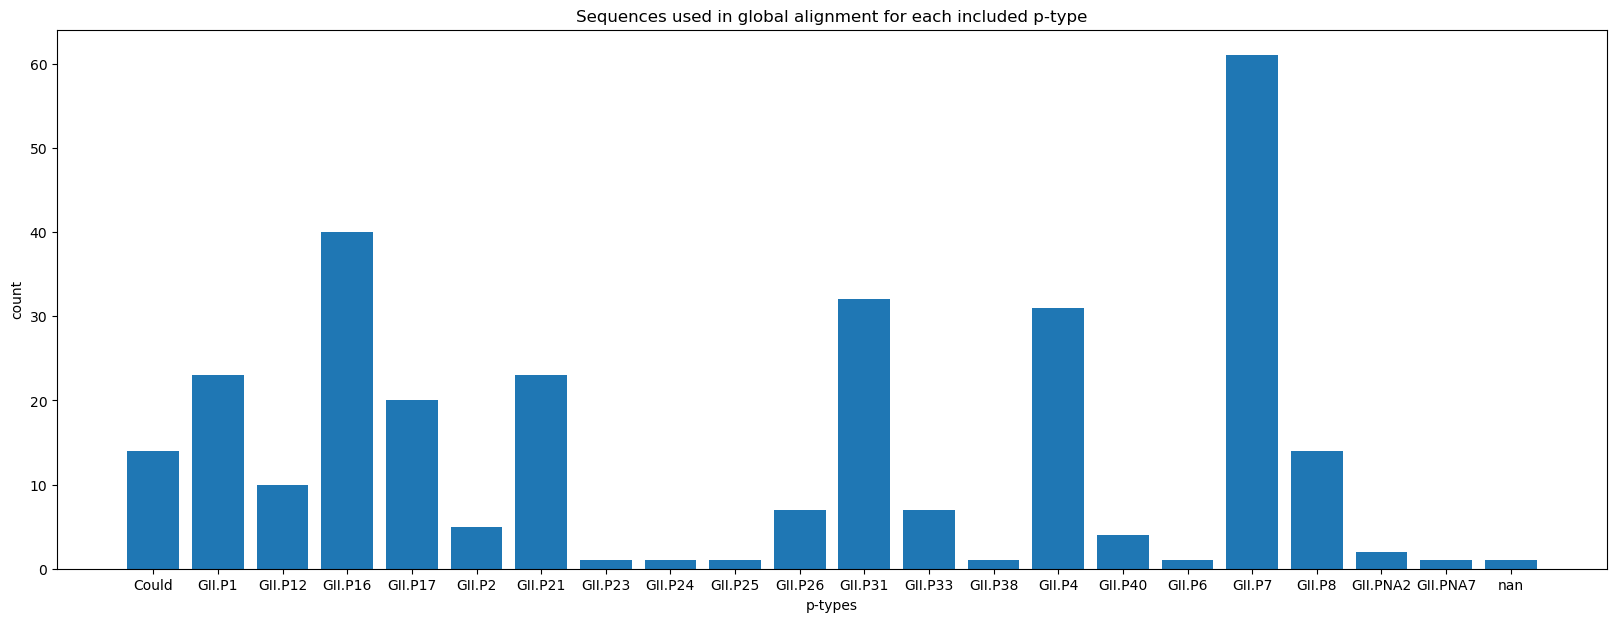

In [90]:
p_types = OrderedDict(sorted(p_type_dict.items(), key = lambda item:item[0]))

# print(genotypes)

plt.figure(figsize=(20, 7))
plt.bar(list(p_types.keys()), list(p_types.values()))
plt.xlabel('p-types')
plt.ylabel('count')
plt.title('Sequences used in global alignment for each included p-type')
plt.show()



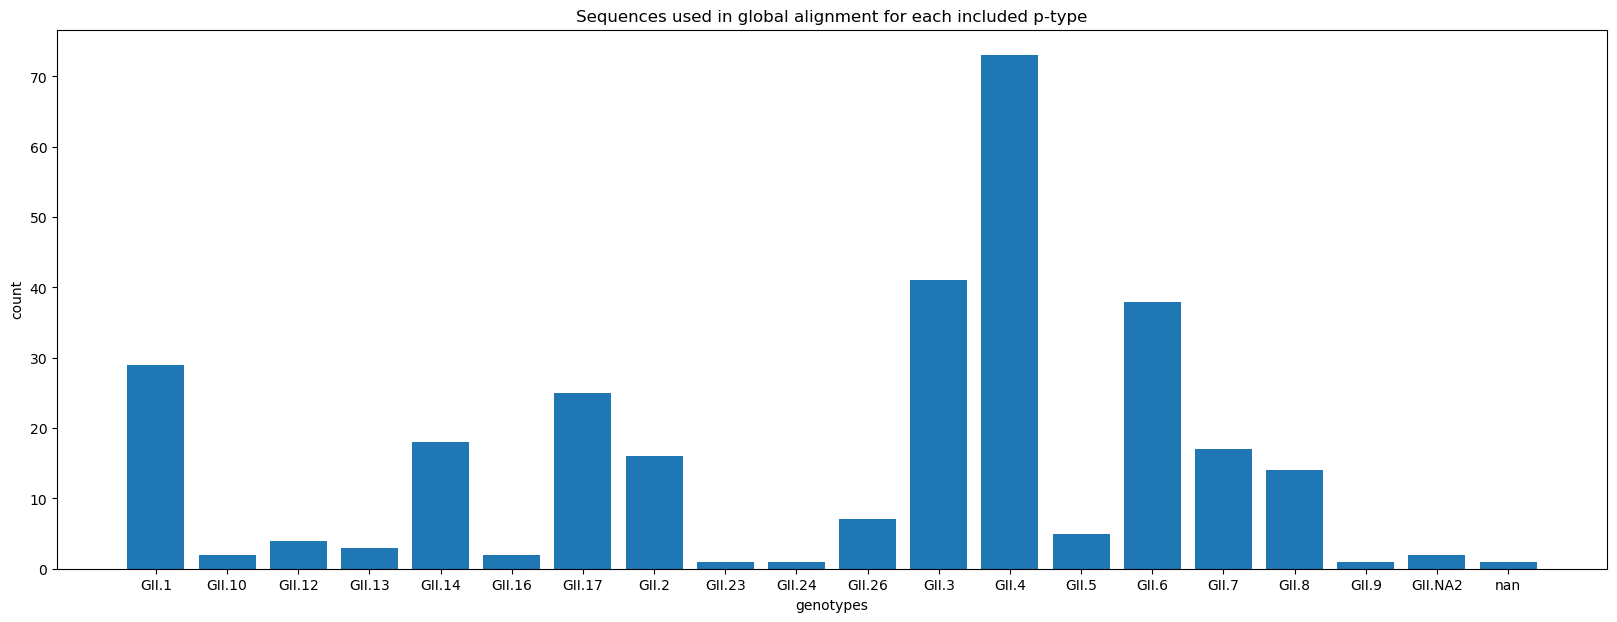

In [91]:
genotypes = OrderedDict(sorted(genotype_dict.items(), key = lambda item:item[0]))
p_types = OrderedDict(sorted(p_type_dict.items(), key = lambda item:item[0]))

# print(genotypes)
plt.figure(figsize=(20, 7))
plt.bar(list(genotypes.keys()), list(genotypes.values()))
plt.xlabel('genotypes')
plt.ylabel('count')
plt.title('Sequences used in global alignment for each included p-type')
plt.show()


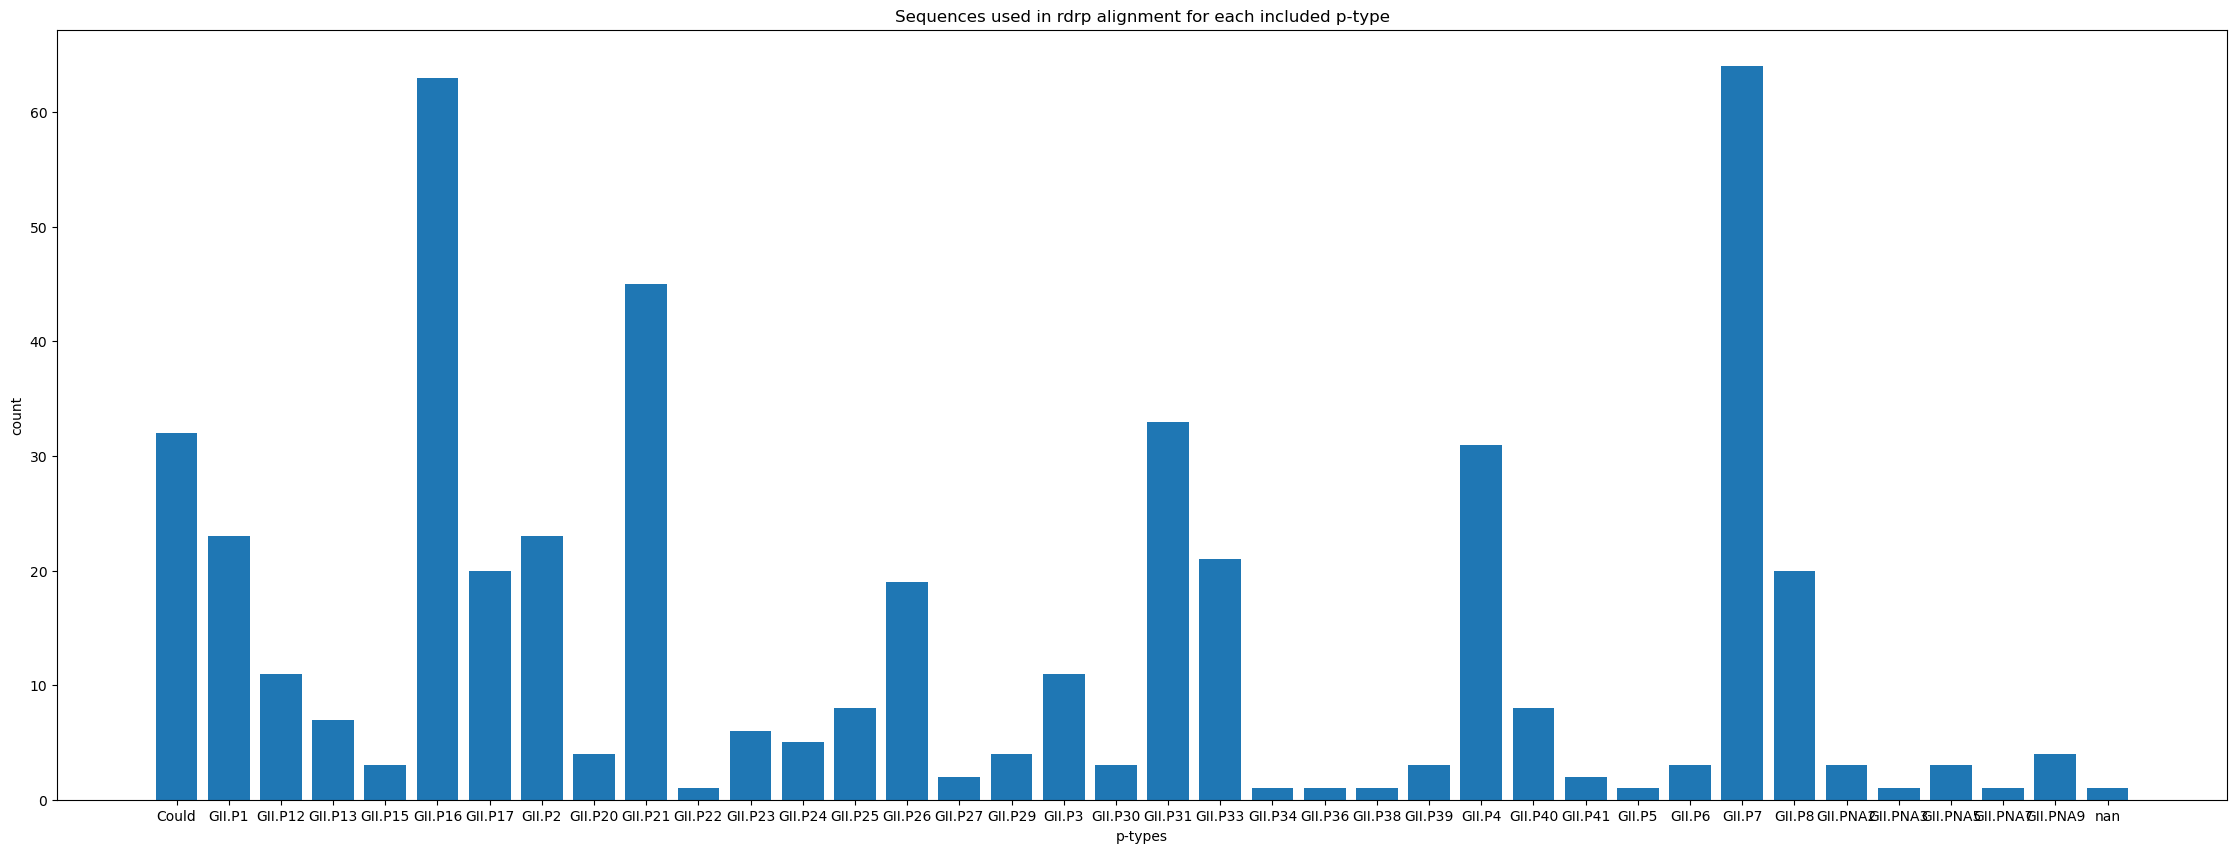

In [92]:
partial_p_types = OrderedDict(sorted(partial_p_type_dict.items(), key = lambda item:item[0]))

# print(genotypes)

plt.figure(figsize=(28, 10))
plt.bar(list(partial_p_types.keys()), list(partial_p_types.values()))
plt.xlabel('p-types')
plt.ylabel('count')
plt.title('Sequences used in rdrp alignment for each included p-type')
plt.show()

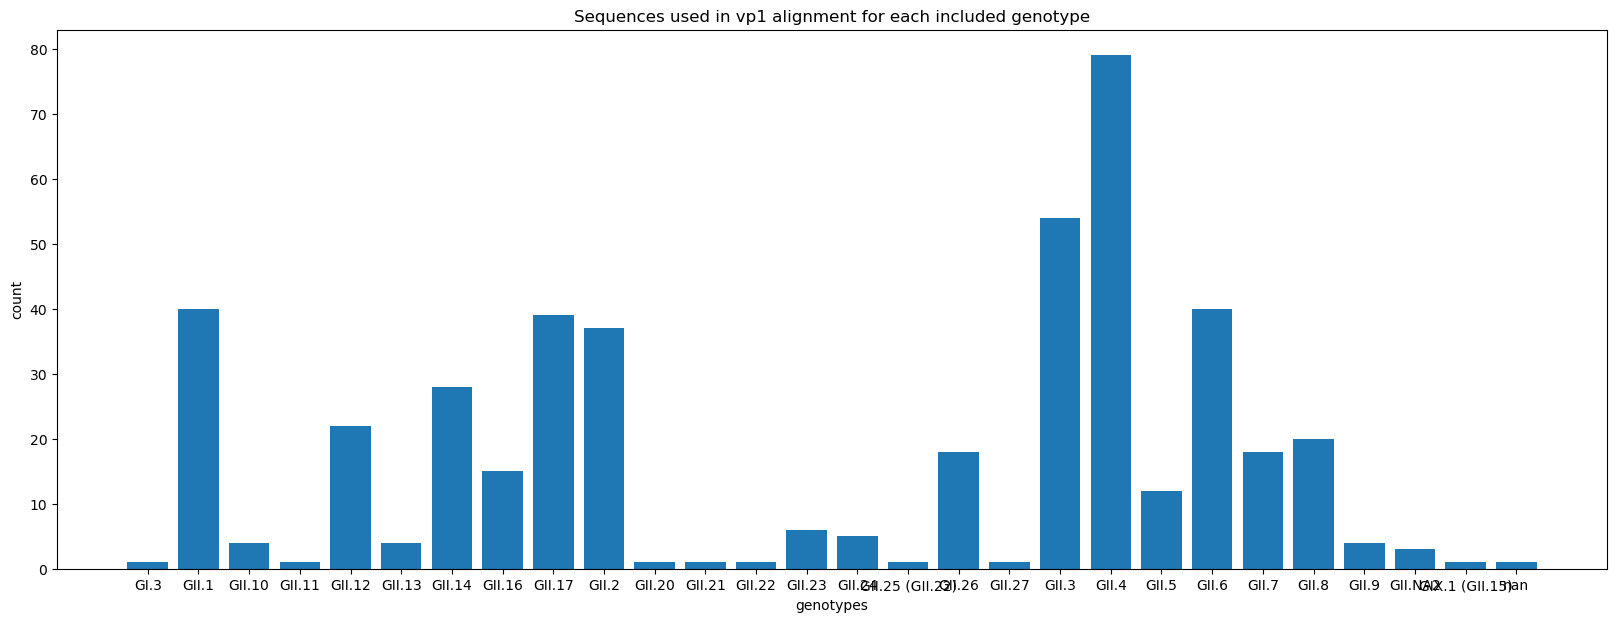

In [93]:
partial_genotypes = OrderedDict(sorted(partial_genotype_dict.items(), key = lambda item:item[0]))

# print(genotypes)

plt.figure(figsize=(20, 7))
plt.bar(list(partial_genotypes.keys()), list(partial_genotypes.values()))
plt.xlabel('genotypes')
plt.ylabel('count')
plt.title('Sequences used in vp1 alignment for each included genotype')
plt.show()

__________________________________---

In [94]:
accessions = set()
partials = set()

df_pa = pd.read_csv(POLYMERASE_ACCESSIONS)



for index, row in df_pa.iterrows():
    # print(row)
    # print()
    accessions.add(row['accession'])

# print(len(accessions))
# print(len(partials))

# print(accessions)


In [95]:
# genotype_dict = {}
p_type_dict = {}

df = pd.read_csv(MERGED_CSV)

for index, row in df.iterrows():
    if row['accession'] in accessions:
        
        if row["p_type"] in p_type_dict:
            p_type_dict[str(row["p_type"])] += 1
        else:
            p_type_dict[str(row["p_type"])] = 1
       
        # if row["genotype"] in genotype_dict:
        #     genotype_dict[str(row["genotype"])] += 1
        # else:
        #     genotype_dict[str(row["genotype"])] = 1


# print(f'genotypes: {genotype_dict}')
# print(sum(genotype_dict.values()))
# print()
print(f'p-types: {p_type_dict}')


p-types: {'GII.P17': 20, 'GII.P16': 17, 'GII.P31': 18, 'GII.P4': 31, 'GII.PNA7': 1, 'GII.P38': 1, 'GII.P26': 8, 'GII.PNA2': 3, 'GII.P33': 21, 'GII.P7': 25, 'GII.P21': 13, 'GII.P2': 23, 'GII.P12': 10, 'GII.P8': 17, 'GII.P1': 23, 'GII.P40': 8, 'GII.P24': 1, 'GII.P23': 2, 'GII.P6': 3, 'GII.P25': 7, 'Could': 17, 'GII.PNA5': 2, 'GII.P15': 3, 'GII.P20': 4, 'GII.P13': 7, 'GII.P39': 3, 'GII.P36': 1, 'GII.P41': 2, 'GII.P30': 3, 'GII.P3': 11, 'GII.P29': 4, 'GII.P34': 1, 'GII.P5': 1, 'GII.P22': 1, 'GII.PNA3': 1, 'GII.PNA9': 4}


In [96]:
# # partial_genotype_dict = genotype_dict.copy()
# partial_p_type_dict = p_type_dict.copy()

# df_pa = pd.read_csv(PARTIAL_SPECIFICATION)

# for index, row in df_pa.iterrows():
#     if row['accession'] in partials:
        
#         if row["p_type"] in partial_p_type_dict:
#             partial_p_type_dict[str(row["p_type"])] += 1
#         else:
#             partial_p_type_dict[str(row["p_type"])] = 1
       
#         if row["genotype"] in genotype_dict:
#             partial_genotype_dict[str(row["genotype"])] += 1
#         else:
#             partial_genotype_dict[str(row["genotype"])] = 1


# # df = pd.read_csv(COMPLETE_SPECIFICATION)

# # for index, row in df.iterrows():
# #     if row['accession'] in accessions:
        
# #         if row["p_type"] in partial_p_type_dict:
# #             partial_p_type_dict[str(row["p_type"])] += 1
# #         else:
# #             partial_p_type_dict[str(row["p_type"])] = 1
       
# #         if row["genotype"] in genotype_dict:
# #             partial_genotype_dict[str(row["genotype"])] += 1
# #         else:
# #             partial_genotype_dict[str(row["genotype"])] = 1


# # print(f'genotypes: {genotype_dict}')
# # print()
# # print(f'p-types: {p_type_dict}')
# print(sum(genotype_dict.values()))
# print(sum(partial_genotype_dict.values()))
# print(len(genotype_dict))
# print(len(partial_genotype_dict))
# print()
# print(sum(p_type_dict.values()))
# print(sum(partial_p_type_dict.values()))
# print(len(p_type_dict))
# print(len(partial_p_type_dict))



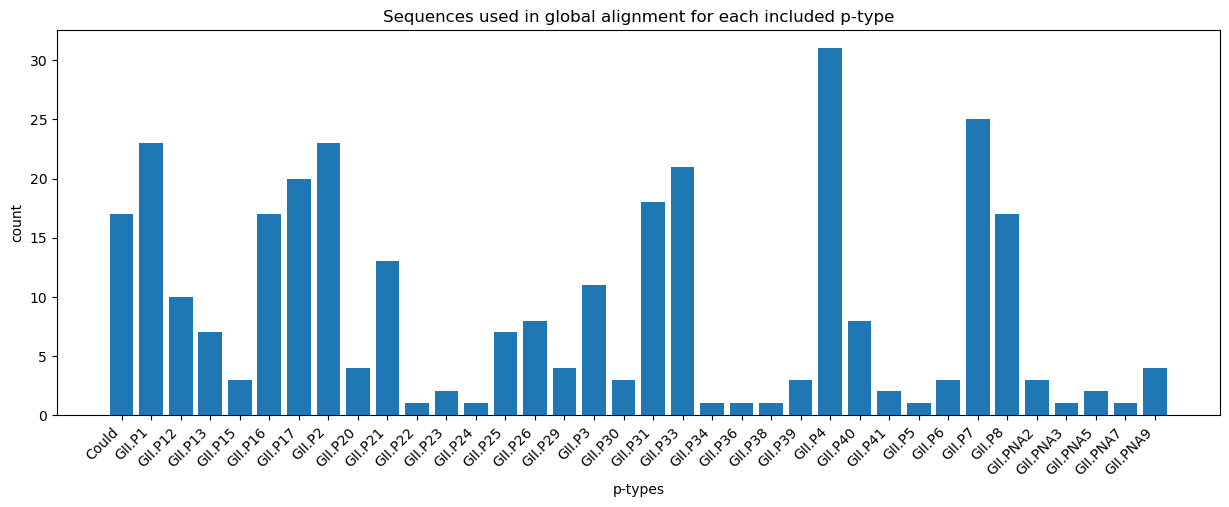

In [97]:
p_types = OrderedDict(sorted(p_type_dict.items(), key = lambda item:item[0]))

# print(genotypes)

plt.figure(figsize=(15, 5))
plt.bar(list(p_types.keys()), list(p_types.values()))
plt.xlabel('p-types')
plt.xticks(rotation=45, ha='right')
plt.ylabel('count')
plt.title('Sequences used in global alignment for each included p-type')
plt.show()

